In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
data = pd.read_csv("Find_S_Dataset.csv")

In [5]:
X = data.iloc[:, :-1]
y = data.iloc[:, -1]


In [6]:
attributes = X.columns.tolist()


In [7]:
S = ['0'] * len(attributes)
G = [['?'] * len(attributes)]

In [16]:
for i in range(len(data)):

    example = X.iloc[i].tolist()
    target = str(y.iloc[i]).lower()

    if target == "yes":

        # Update S
        for j in range(len(attributes)):

            if S[j] == '0':
                S[j] = example[j]

            elif S[j] != example[j]:
                S[j] = '?'

        # Remove inconsistent G
        new_G = []

        for g in G:

            valid = True

            for j in range(len(attributes)):

                if g[j] != '?' and g[j] != example[j]:
                    valid = False
                    break

            if valid:
                new_G.append(g)

        G = new_G

    elif target == "no":

        # Specialize G
        new_G = []

        for g in G:

            for j in range(len(attributes)):

                if g[j] == '?':

                    for value in X.iloc[:, j].unique():

                        if value != example[j]:

                            new_g = g.copy()
                            new_g[j] = value

                            valid = True

                            for k in range(len(attributes)):

                                if S[k] != '0' and S[k] != '?':

                                    if new_g[k] != '?' and new_g[k] != S[k]:
                                        valid = False
                                        break

                            if valid:
                                new_G.append(new_g)

        G = new_G
    if i < 10:

        print("\n======================================")
        print("Iteration:", i + 1)
        print("Example:", example)
        print("Target:", target)
        print("======================================")

        print("S =", S)

        print("G =")

        if len(G) == 0:
            print("G is empty")
        else:
            for g in G:
                print(g)


# ---------- FINAL RESULT ----------

print("\n\n======================================")
print("FINAL CANDIDATE ELIMINATION RESULT")
print("======================================")

print("\nSpecific Hypothesis (S):")
print(S)

print("\nGeneral Hypotheses (G):")

if len(G) == 0:
    print("G is empty")
else:
    for i, g in enumerate(G, 1):
        print("G", i, ":", g)


Iteration: 1
Example: ['Sunny', 'Warm', 'Normal', 'Strong', 'Warm', 'Same']
Target: yes
S = ['Sunny', 'Warm', 'Normal', 'Strong', 'Warm', 'Same']
G =
['?', '?', '?', '?', '?', '?']

Iteration: 2
Example: ['Sunny', 'Warm', 'High', 'Strong', 'Warm', 'Same']
Target: yes
S = ['Sunny', 'Warm', '?', 'Strong', 'Warm', 'Same']
G =
['?', '?', '?', '?', '?', '?']

Iteration: 3
Example: ['Rainy', 'Cold', 'High', 'Strong', 'Warm', 'Change']
Target: no
S = ['Sunny', 'Warm', '?', 'Strong', 'Warm', 'Same']
G =
['Sunny', '?', '?', '?', '?', '?']
['?', 'Warm', '?', '?', '?', '?']
['?', '?', 'Normal', '?', '?', '?']
['?', '?', '?', '?', '?', 'Same']

Iteration: 4
Example: ['Sunny', 'Warm', 'High', 'Strong', 'Cool', 'Change']
Target: yes
S = ['Sunny', 'Warm', '?', 'Strong', '?', '?']
G =
['Sunny', '?', '?', '?', '?', '?']
['?', 'Warm', '?', '?', '?', '?']

Iteration: 5
Example: ['Cloudy', 'Warm', 'Normal', 'Weak', 'Warm', 'Same']
Target: yes
S = ['?', 'Warm', '?', '?', '?', '?']
G =
['?', 'Warm', '?', '

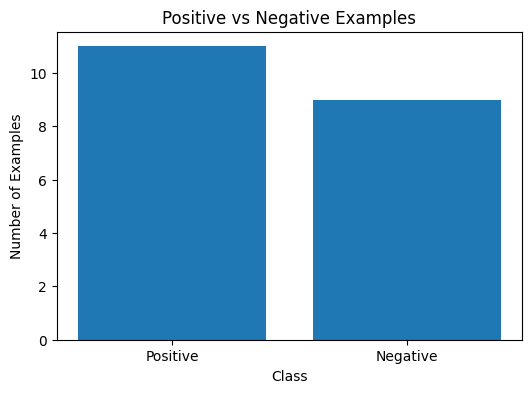

In [17]:
positive = sum(y.astype(str).str.lower() == "yes")
negative = sum(y.astype(str).str.lower() == "no")

plt.figure(figsize=(6, 4))

plt.bar(
    ["Positive", "Negative"],
    [positive, negative]
)

plt.title("Positive vs Negative Examples")
plt.xlabel("Class")
plt.ylabel("Number of Examples")

plt.show()


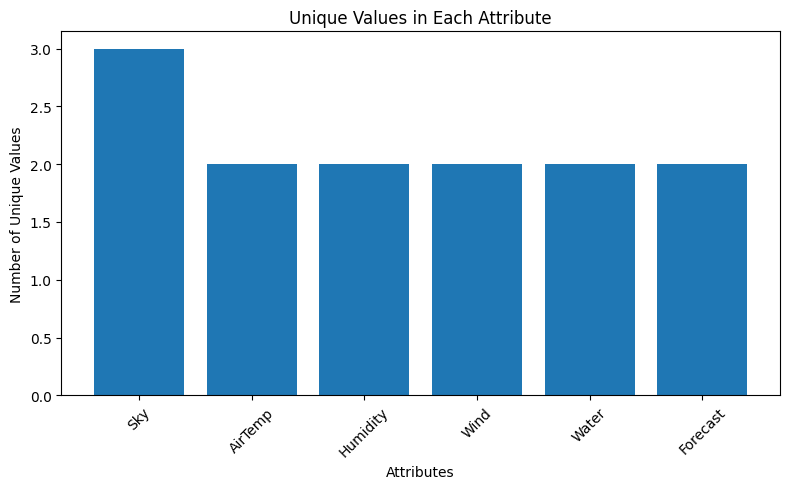

In [18]:
unique_values = X.nunique()

plt.figure(figsize=(8, 5))

plt.bar(
    unique_values.index,
    unique_values.values
)

plt.title("Unique Values in Each Attribute")
plt.xlabel("Attributes")
plt.ylabel("Number of Unique Values")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()